# Введение в NumPy

## Мотивация к изучению

Во многих прикладных задачах вам предстоит иметь дело с данными, хранящимися в массивах различной размерности. Так, например, при работе с радиолокационными или акустическими сигналами вы, скорее всего, будете иметь дело с одномерными массивами. Элементы таких массивов - числа с плавающей точкой, значения которых соответствуют значению амплитуды сигнала в определенный момент времени. При анализе одноканальных (черно-белых) изображений вам предстоит обрабатывать двумерные массивы, в ячейках которых закодированы яркости пикселей изображения. Наконец, при работе с цветными изображениями вы столкнетесь с многомерными массивами - тензорами. Также многомерные массивы лежат в основе большого количества алгоритмов и технологий, к числу которых относятся, например, сверточные нейронные сети.

![image-struct](./images/image_struct.png)

Из всего выше сказанного, очевидно, что необходим инструмент для работы с массивами большой размерности, содержащими большое количество элементов. Из заголовка семинара и из хода повествования вам должно быть очевидно, что к числу таких инструментов и относится `NumPy`. Однако, прежде, чем перейти к знакомству с ним, давайте подумаем, почему мы не можем использовать "чистый" Python для работы с большими и многомерными массивами. Решим пару задач.

## Задача 1. Перегруз

### Познавательная минутка

Думаю, все вы слышали звук перегруженной гитары (если это не так, могу вам только посочувствовать и посоветовать послушать, например, *Black Sabbath - "Iron Man"*). Давайте разберемся откуда берется этот звук. Итак, в нашем распоряжении есть электрогитара и гитарный усилитель. С помощью электрогитары мы получаем некоторый электромагнитный сигнал, который поступает на вход усилителя по кабелю. Внутри гитарного усилителя происходит, как это не странно, усиление входного сигнала. Усиленный сигнал поступает на динамик усилителя, и мы слышим музыку. Однако амплитудный диапазон динамика не резиновый. Динамик не может воспроизводить любой усиленный сигнал в исходном виде без искажений. Когда значение амплитуды усиленного сигнала превышает максимально возможное значение амплитуду, которую способен воспроизвести динамик, происходит так называемый клиппинг, т.е. обрезание пиков сигнала. В результате мы слышим усиленный, но искаженный сигнал и получаем тот самый эффект перегруза.

![signal-clipping](./images/clipping.png)

### Задание

Для того, чтобы понять, почему "чистый" Python не подойдет для работы с большими массивами данных, реализуем описанный выше алгоритм клиппинга. Чтобы реализовать алгоритм, нам потребуется:
- Создать сам сигнал;
- Усилить сигнал;
- Обрезать пики сигнал;

Для каждого описанного выше шага реализуем отдельную функцию.

**Функция создания сигнала**

В качестве базового сигнала используется функция $sin(x)$.

*Входные данные*:
- `sampling_period` - положительное число с плавающей точкой, соответствующее периоду дискретизации (шаг по времени);
- `signal_amount` - натуральное число (считаем, что натуральные числа начинаются с $1$), количество дискретов в сигнале;
- `modulation` - `Callable`-объект или `None`, функция модуляции сигнала. Если `None`, то модуляция не осуществляется. Функция модуляции должна иметь следующую сигнатуру:
    ```python
    def modulation(signal: float) -> float:
        ...
    ```

*Выходные данные*:
- Объект типа `list[float]` - сгенерированный и промодулированный сигнал. Фактически, результат - это список, состоящий из `signal_amount` элементов, `i`-ый элемент которого - это значение функции $sin(x) * modulation(x)$ в точке `sampling_period * i`.

**Функция усиления**

*Входные данные*:
- `signal` - список чисел с плавающей точкой, входной сигнал;
- `gain` - положительное число с плавающей точкой, большее нуля, коэффициент усиления;

*Выходные данные*:
- Список чисел с плавающей точкой, `i`-ый элемент которого соответствует `i`-ому элементу списка `signal`, увеличенного в `gain` раз.

**Функция клиппинга**

*Входные данные*:
- `signal` - список чисел с плавающей точкой, входной сигнал;
- `threshold` - положительное число с плавающей точкой, большее нуля; уровень, по которому будет происходить обрезание сигнала;

*Выходные данные*:
- Список чисел с плавающей точкой. Значение `i`-ого элемента результирующего списка описывается следующим выражение:

$$res_i = \begin{cases} signal_i, |signal_i| \le threshold \\ threshold * sign(signal_i), |signal_i| \gt threshold \end{cases}$$

**Необходимые импорты:**

In [2]:
import math
import pathlib
import sys

from typing import Callable, Optional

from utils import read_floats_from_bytes
from utils import visualize_1d_array

**Константы:**

In [3]:
signal_amount = int(1e7)                    # количество отсчетов в сигнале                          
sampling_period = 6 * math.pi *1e-7         # период дискретизации
gane = 10                                   # коэффициент усиления
threshold = 4                               # порог
eps = 1e-6                                  # точность

**Функция модуляции:**

In [4]:
def modulate(signal: float) -> float:
    return math.exp(-0.1 * signal)

**Решение:**

In [5]:
def get_signal(
    sampling_period: float,
    signal_amount: int,
    modulation: Optional[Callable[[float], float]] = None,
) -> list[float]:
    signal = []
    flag = True
    if modulation(2) == None:
        flag = False
    for i in range(signal_amount):
        if flag:
            signal.append(modulation(sampling_period*i)*math.sin(sampling_period*i))
        else:
            signal.append(math.sin(sampling_period*i))
            
    return signal


def amplify_signal(
    signal: list[float],
    gane: float,
) -> list[float]:
    signal_amplified = []
    for i in range(len(signal)):
        signal_amplified.append(signal[i] * gane)
    return signal_amplified


def clip_signal(
    signal: list[float],
    threshold: float,
) -> list[float]:
    signal_clipped = []
    for i in range(len(signal)):
        if abs(signal[i]) > threshold:
            signal_clipped.append(threshold * (signal[i] / abs(signal[i])))
        else:
            signal_clipped.append(signal[i])
    return signal_clipped

**Профилирование решения:**

In [6]:
# %%timeit -r 1 -n 1
signal = get_signal(sampling_period, signal_amount, modulate)
signal_amplified = amplify_signal(signal, gane)
signal_clipped = clip_signal(signal_amplified, threshold)

print(f"signal size: {sys.getsizeof(signal)} bytes")

signal size: 89095160 bytes


**Визуализация результата:**

In [7]:
assert signal is not signal_amplified
assert signal_amplified is not signal_clipped

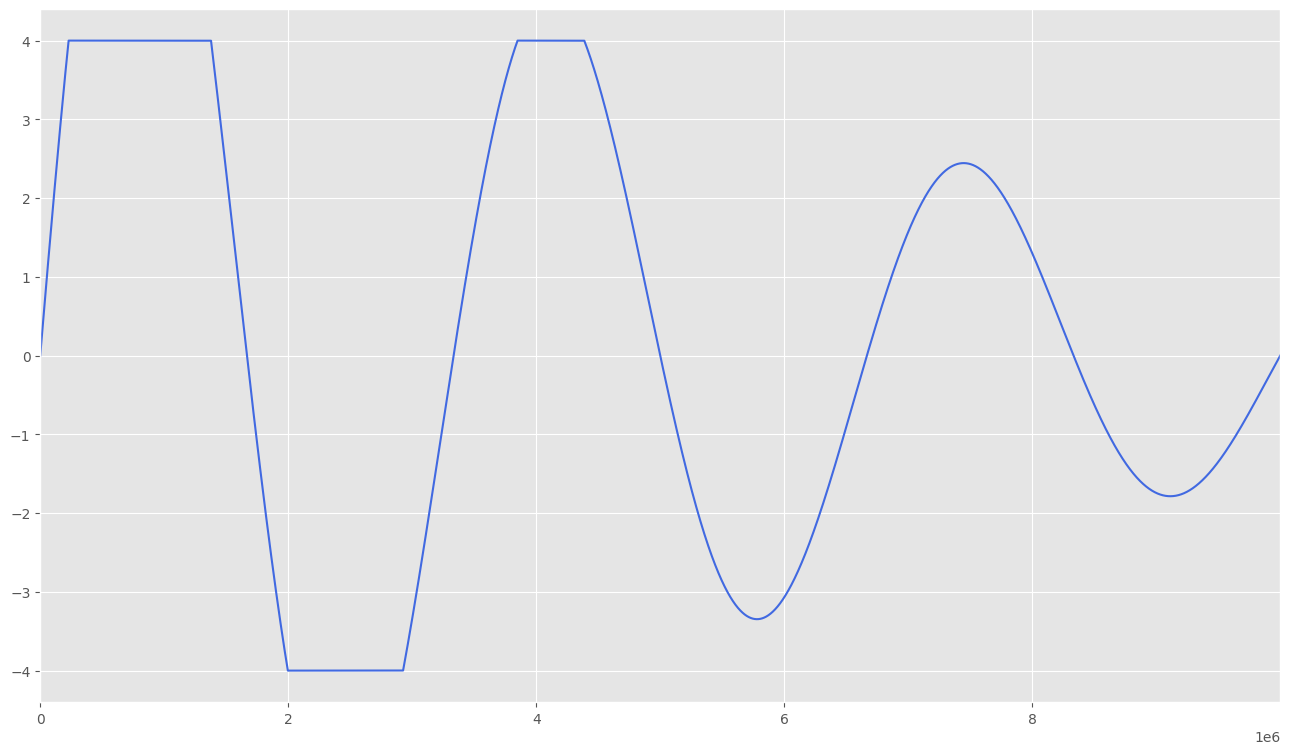

In [8]:
visualize_1d_array(ordinate=signal_clipped)

**Сравнение результатов с эталоном:**

In [9]:
path_to_reference = pathlib.Path("./test_data/signal_clipped.log")
assert path_to_reference.exists(), "no reference data for testing"

signal_referense = read_floats_from_bytes(
    signal_amount, path_to_reference
)

assert all(
    abs(amp - amp_ref) < eps
    for amp, amp_ref in zip(signal_clipped, signal_referense)
)

Удалим списки, чтобы они не занимали место в памяти:

In [10]:
del signal
del signal_amplified
del signal_clipped
del signal_referense

Как можно видеть, уже на 10 миллионах чисел с плавающей точкой у нас начинаются проблемы. Клиппинг происходит достаточно медленно. Может, дела обстоят иначе для многомерных массивов?

## Задача 2. Матрицы

### Часть 1. Перемножение

Задача проста: необходимо реализовать функцию, которая занималась бы перемножением двух матриц по всем правилам линейной алгебры. Если матрицы не могу быть перемножены, необходимо возбудить исключение `ShapeMismatchError`.

*Входные данные*:
- `lhs` - двумерный массив, расположенный слева от оператора перемножения матриц; элементы массива - числа с плавающей точкой;
- `rhs` - двумерный массив, расположенный справа от оператора перемножения матриц; элементы массива - числа с плавающей точкой;

Гарантируются, что матрицы содержат хотя бы одну строку и хотя бы один столбец.

*Выходные данные*:
- Двумерный массив - результат произведения матрицы `lhs` на матрицу `rhs` в соответствии со всеми правилами линейной алгебры.

*Сторонние эффекты*:
- Если матрицы не могут быть перемножены между собой, необходимо возбудить исключение `ShapeMismatchError`. 


**Необходимые импорты:**

In [11]:
from random import randint

**Константы:**

In [12]:
columns_amount = 1000           # число колонок в матрице для тестирования
rows_amount = 500               # число строк в матрице для тестирования

bottom = -10                    # нижняя граница значений чисел в матрице
top = 10                        # верхняя граница значений чисел в матрице

**Решение:**

In [13]:
class ShapeMismatchError(Exception):
    """Возбуждается, если матрицы не могут быть перемножены."""


def multiply_matrices(
    lhs: list[list[float]],
    rhs: list[list[float]],
) -> list[list[float]]:
    # ваш код
    return [[0]]

**Тестирование решения:**

In [14]:
lhs = [
    [7, -1, -4],
    [-1, 5, -1],
]
rhs = [
    [-2, -5],
    [-5, -6],
    [-5, 3],
]
reference = [
    [11, -41],
    [-18, -28]
]

In [15]:
result = multiply_matrices(lhs, rhs)

assert all(
    all(
        num_res == num_ref 
        for num_res, num_ref in zip(row_res, row_ref)
    )
    for row_res, row_ref in zip(result, reference)
)

was_raised = False

try:
    result = multiply_matrices(lhs, rhs[:2])

except ShapeMismatchError:
    was_raised = True

assert was_raised

AssertionError: 

**Прифилирование решения:**

In [ ]:
# %%timeit -r 1 -n 1
lhs = [
    [randint(bottom, top) for _ in range(columns_amount)]
    for _ in range(rows_amount)
]

rhs = [
    [randint(bottom, top) for _ in range(rows_amount)]
    for _ in range(columns_amount)
]

result = multiply_matrices(lhs, rhs)

In [ ]:
del lhs
del rhs
del result

### Часть 2. Транспонирование

Транспонируйте матрицу.

*Входные данные*:
- `matrix` - двумерный массив, состоящий из чисел с плавающей точкой - матрица, которую необходимо транспонировать;

*Выходные данные*:
- Двумерный массив, состоящий из чисел с плавающей точкой - транспонированная матрица.

**Решение:**

In [ ]:
def transpose(matrix: list[list[float]]) -> list[list[float]]:
    # ваш код
    return matrix

**Тестирование:**

In [ ]:
matrix = [
    [-2, -5],
    [-5, -6],
    [-5, 3],
]
reference = [
    [-2, -5, -5],
    [-5, -6, 3],
]

In [ ]:
transposed = transpose(matrix)

assert transposed is not matrix
assert all(
    all(
        num_res == num_ref 
        for num_res, num_ref in zip(row_res, row_ref)
    )
    for row_res, row_ref in zip(transposed, reference)
)

**Профилирование решения:**

In [ ]:
# %%timeit -r 1 -n 1
size = int(2e3)

matrix = [
    [randint(bottom, top) for _ in range(size)]
    for _ in range(size)
]

transposed = transpose(matrix)

In [ ]:
del transposed

Как видите с многомерными массивами "чистый" Python работает достаточно медленно. Тут-то на сцену и выходит `NumPy`.


## Что такое NumPy?

Прежде чем перейти к самому NumPy, давайте разберемся, почему работа с большими массивами данных средствами Python настолько неэффективна. Ключ к пониманию кроется в способе хранения данных в Python. Напомню, что любой объект в CPython - это не просто ячейка памяти со значением, как это было в C или C++. Объект в CPython - это указатель на структуру C. В этой структуре, помимо самого значения объекта хранятся метаданные объекта, которые используются интерпретатором Python. К числу таких данных относится тип объекта, счетчик ссылок, размер объекта. Массивы же - это не просто указатели на непрерывные блоки памяти с необходимыми данными, которые можно было бы быстро обрабатывать за счет кеширования. Массивы в CPython - это непрерывные области памяти, в которых хранятся адреса объектов CPython в памяти. Таким образом при обработке массива, мы читаем данные из памяти два раза: сначала адрес объекта, а потом сам объект. При этом указатели могут указывать на произвольные области памяти, которые не получится эффективно кешировать. Такой способ хранения данных с одной стороны позволяет иметь коллекции объектов различных типов данных, но с другой стороны сильно снижает эффективность обработки этих данных. 

NumPy подходит иначе к хранению данных. `NumPy` (сокращение от *Numerical Python*) - библиотека для эффективной работы с плотными массивами однородных данных. Особенно стоит выделить слово "однородными", ведь именно оно позволяет понять причину эффективности NumPy. Массивы NumPy являются оберткой вокруг C-массивов, т.е. массив NumPy инкапсулирует указатель на непрерывный блок в памяти, в котором хранятся данные одного типа. Это сильно ускоряет работу с этими данными и даже позволяет сэкономить память.

![arrays](./images/arrays.png)

## Быстрая демонстрация возможностей

Чтобы убедиться, что эффективность NumPy - это не пустое преувеличение, реализуем решение всех поставленных выше задач с помощью NumPy.

In [16]:
import numpy as np

from utils import visualize_1d_array

### Перегруз

In [ ]:
signal_amount = int(1e7)    # количество отсчетов в сигнале                          
gane = 10                   # коэффициент усиления
threshold = 4               # порог
eps = 1e-6                  # точность

In [ ]:
# %%timeit -r 1 -n 1
time = np.linspace(0, 6 * np.pi, signal_amount)

signal = np.sin(time) * np.exp(-0.1 * time)
signal_amplified = gane * signal

signal_clipped = signal_amplified.copy()
mask = np.abs(signal_clipped) > threshold
signal_clipped[mask] = np.sign(signal_clipped[mask]) * threshold

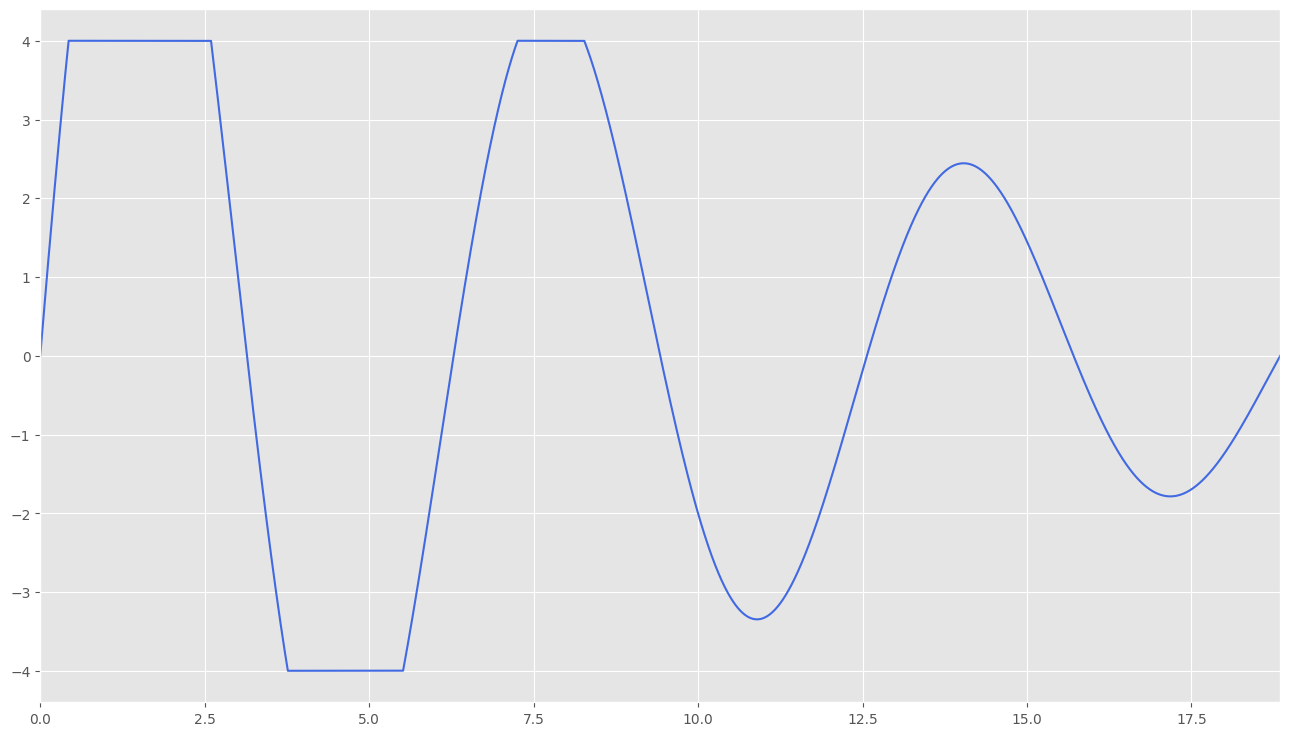

In [ ]:
visualize_1d_array(abscissa=time, ordinate=signal_clipped)

In [ ]:
del signal
del signal_amplified
del signal_clipped

### Перемножение матриц

In [ ]:
columns_amount = 1000           # число колонок в матрице
rows_amount = 500               # число строк в матрице

bottom = -10                    # нижняя граница значений числе в матрице
top = 10                        # верхняя граница значений числе в матрице

In [ ]:
# %%timeit -r 1 -n 1
lhs = np.random.randint(
    low=bottom,
    high=top,
    size=(rows_amount, columns_amount),
)
rhs = np.random.randint(
    low=bottom,
    high=top,
    size=(columns_amount, rows_amount),
)

result = lhs @ rhs
result

array([[-1005,  -450,   282, ...,   381,   482, -1205],
       [ 1392,   156,  1069, ...,  -978,  -938,  -158],
       [  949,   577,   129, ...,   572, -1226, -1227],
       ...,
       [  168,   314,  -575, ..., -1580,  -104,  -285],
       [ 1512,   595, -1181, ...,  -273,   275,  1103],
       [ -489,   101,  -644, ..., -1134,  1267,  -474]],
      shape=(500, 500), dtype=int32)

In [ ]:
del lhs
del rhs
del result

### Транспонирование

In [ ]:
# %%timeit -r 1 -n 1

matrix = np.random.randint(
    low=bottom,
    high=top,
    size=(rows_amount, columns_amount),
)

transposed = matrix.T
del transposed

Как вы видите NumPy позволяет решать задачи с матричными вычислениями на порядки быстрее.

## Основы NumPy

### Создание массивов

Как вы поняли из всего сказанного выше, центральным элементов библиотеки является многомерный массив. Именно поэтому мы начнем знакомство с создания массивов. Обычный и самый распространненный способ создания массива - функция `array()`, которая принимает на вход массиво-подобные объекты и возвращает массив NumPy.

#### Создание массивов из объектов Python

In [17]:
array_python = list(range(5))

array_ints = np.array(array_python)
print(f"{array_ints = }")

array_python[3] = 3.14

array_floats = np.array(array_python)
print(f"{array_floats = }")

array_python[3] = 3

array_doubles = np.array(array_python, dtype=np.float64)
print(f"{array_doubles = }")

array_of_objects = [
    1, 2.27, [1, 2, 3], {"a": 1, "b": 2}
]
array_of_objects = np.array(array_of_objects, dtype=object)
print(f"{array_of_objects = }")

array_2d = np.array(
    [[i + j for j in range(5)] for i in range(5)]
)
print(array_2d)

array_ints = array([0, 1, 2, 3, 4])
array_floats = array([0.  , 1.  , 2.  , 3.14, 4.  ])
array_doubles = array([0., 1., 2., 3., 4.])
array_of_objects = array([1, 2.27, list([1, 2, 3]), {'a': 1, 'b': 2}], dtype=object)
[[0 1 2 3 4]
 [1 2 3 4 5]
 [2 3 4 5 6]
 [3 4 5 6 7]
 [4 5 6 7 8]]


Массив NumPy содержит данные одного типа. При попытке создания массива из разнородных данных NumPy, если это возможно, будет производить повышающее приведение типов до тех пор, пока все данные не будут унифицированы. 

Так во втором примере, из-за наличия в данных числа `3.14`, итоговый тип данных массива - `float`. В четвертом примере NumPy не сможет самостоятельно привести данные к одному типу, поэтому нам пришлось указать его явно. Тип `object` наиболее общий и означает, что массив состоит из объектов языка Python (в нашем примере `int`, `float`, `list` и `dict`).

При необходимости можно явно указать желаемый тип данных, путем присвоение аргументу `dtype` допустимого значения. 

Также обратите внимание на последний пример. В NumPy возможно создание многомерных массивов из списков со вложенными списками. Однако для этого требуется, чтобы вложенные списки имели одинаковый размер. Так в нашем примере вложенные списки интерпретируются, как строки двухмерной матрицы.

#### Создание массивов "с нуля"

Мы не всегда имеем под рукой объект, который бы хотелось представить в виде многомерного массива NumPy. Иногда целесообразно, или даже необходимо, создать новый объект "с нуля". Для этих целей в NumPy есть ряд функций.

**zeros/ones/full:**

Это набор функций, которые позволяют создавать массивы, заполненные одинаковыми элементами. Так функция `zeros` позволяет создать массив, заполненный нулями, `ones` - массив, заполненный единицами, а `full` - массив, заполненный элементами с указанным значением. Поэтому сигнатуры функций очень похожи между собой.

In [18]:
zeros_1d = np.zeros(shape=10, dtype=np.uint8)
ones_1d = np.ones(shape=5, dtype=np.uint32)

zeros_3d = np.zeros(shape=(3, 3, 3), dtype=np.float32)
full_2d = np.full(shape=(5, 5), fill_value=255, dtype=np.uint8)

print(f"Zeros 1D:\n{zeros_1d}", end="\n\n")
print(f"Zeros 3D:\n{zeros_3d}", end="\n\n")
print(f"Ones 1D:\n{ones_1d}", end="\n\n")
print(f"Full 2D:\n{full_2d}")

Zeros 1D:
[0 0 0 0 0 0 0 0 0 0]

Zeros 3D:
[[[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]

 [[0. 0. 0.]
  [0. 0. 0.]
  [0. 0. 0.]]]

Ones 1D:
[1 1 1 1 1]

Full 2D:
[[255 255 255 255 255]
 [255 255 255 255 255]
 [255 255 255 255 255]
 [255 255 255 255 255]
 [255 255 255 255 255]]


Эти функции могут быть полезными при создании некоторых заготовок или аккумуляторов для вычислений.

**arange**:

Полезно уметь создавать не только массивы, заполненные одинаковыми значениями, но и массивы, чьи элементы имеют разные значения. Одна из функций, которая позволяет создать новый массив с элементами, значения которых различаются - функция `np.arange`. Фактически, с помощью `np.arange` можно сгенерировать массив, элементы которого - числа, описывающие некоторую арифметическую прогрессию. Аргументы функции `np.arange` во многом повторяют аргументы встроенного объекта `range`: `start` - значение первого элемента; `stop` - значение последнего элемента, не включительно; `step` - шаг арифметической прогрессии. Как и в случае `range` аргументы `start` и `stop` можно опустить, в этом случае в качестве их значений будут использованы числа 0 и 1, соответственно.

По умолчанию `np.arange` создает массив целых чисел. Однако при необходимости вы можете явно указать тип данных элементов созданного массива с помощью аргумента `dtype`. Более того, в отличие от `range`, `np.arange` умеет работать с числами с плавающей точкой.

In [ ]:
arange_int = np.arange(10)
print(f"integer array:\n{arange_int}")

arange_float = np.arange(0, 5, 0.5)
print(f"float array:\n{arange_float}")

Далее в курсе мы с вами познакомимся с индексаций массивов с помощью массивов индексов. `np.arange` особенно полезна для этих целей.

**linspace:**

В задаче на вычисление перегруза для генерации сигнала нам потребовалось вычислять значение времени, зная шаг дискретизации. Однако нам не всегда может быть известен шаг дискретизации, но может быть известен диапазон значений и количество отсчетов, которые необходимо взять из данного диапазона. Поскольку такая задача является типовой и встречается на практике очень часто, в NumPy реализована специальная функция для этого:

In [ ]:
np.linspace(0, np.pi, 32)

**Немного о random:**

В ряде задач бывает полезно создать массивы, заполненые случайными числами из определенного распределения вероятностей. Так, например, в глубоком обучении для повышения качества модели с функцией активации `ReLU` в начале обучения рекомендуется инициализировать веса случайными числами из нормального закона распределения.

Эту задачу можно решить, используя подмодуль NumPy, который носит характерное название `random`.

In [ ]:
normal = np.random.normal(loc=0, scale=1, size=(3, 3))
uniform = np.random.uniform(low=-10, high=10, size=(3, 3))
randomint = np.random.randint(0, 10, size=(3, 3))

print(f"Normal:\n{normal}", end="\n\n")
print(f"Uniform:\n{uniform}", end="\n\n")
print(f"Randint:\n{randomint}", end="\n\n")

**eye/diag**

Поскольку NumPy часто используется для реализации вычислений из линейной алгебры, о чем мы поговорим в будущем, в нем есть отдельные функции для создания единичных матриц и диагональных матриц.

In [ ]:
eye_square = np.eye(5)
eye_rectangle = np.eye(3, 5)
diag = np.diag([3, 5, 9])

print(f"Eye Square:\n{eye_square}", end="\n\n")
print(f"Eye Rectangle:\n{eye_rectangle}", end="\n\n")
print(f"Diagonal:\n{diag}", end="\n\n")

**empty:**

В ряде задач полезно создать "пустой" массив, т.е. массив, который не инициализирован никакими данным. Этот массив может быть использован в качестве буффера, в который будут записываться результаты различных матричных операций.

In [ ]:
np.empty(5)

### Атрибуты массивов

In [ ]:
def print_attributes(array: np.ndarray) -> None:
    print('\n--------------------------------------------------')
    print(f'\n{array}\n')
    print(f'Array shape: {array.shape};')
    print(f'Array dimension: {array.ndim};')
    print(f"Array element's amount: {array.size};")
    print(f"Array element's size: {array.itemsize}")
    print(f'Array memory space: {array.nbytes};')
    print('--------------------------------------------------')

In [ ]:
arrays = [np.random.uniform(0, 10, size=3),
          np.random.uniform(0, 10, size=(3, 3)),
          np.random.uniform(0, 10, size=(3, 3, 3))]

for array in arrays:
    print_attributes(array)

### Доступ к элементам

In [ ]:
arr_1d, arr_2d, arr_3d = arrays

#### Индексация

Индексация массивов в NumPy представляет собой улучшенную индексацию списков в Python. Сами по себе массивы NumPy - изменяемый тип данных, т.е. мы можем перезаписывать элементы с помощью индексации.

In [ ]:
line_len, fill_val = 80, "-"

print("Python Way".center(line_len, fill_val))
print(f"1D:\n{arr_1d[0]}")
print(f"2D:\n{arr_2d[0][2]}")
print(f"3D:\n{arr_3d[0][1][2]}", end="\n\n")

print("NumPy Way".center(line_len, fill_val))
print(f"2D:\n{arr_2d[0, 2]}")
print(f"3D:\n{arr_3d[0, 1, 2]}")

#### Срезы

В одномерном случае срезы аналогичны срезам списков в Python.

In [ ]:
numbers = np.arange(20)

print(numbers)
print(numbers[5: 10])
print(numbers[::2])
print(numbers[1::2])
print(numbers[::-1])

Однако, помимо знакомых нам одномерных срезов, в NumPy есть крайне удобные многомерные срезы:

In [ ]:
print(arr_2d, end="\n\n")

arr_2d[1:, 1:] = 100
print(arr_2d, end="\n\n")
print(arr_2d[::2, ::2], end="\n\n")
print(arr_2d[::-1, 0], end="\n\n")

Важное замечание, которое стоит держать в голове: в отличие от списков в Python, срезы массивов в NumPy возвращают не новый объект, а указатель на область в памяти с элементами существующего объекта. Т.е. связав результат среза с новой переменной, у вас есть возможность безвозвратно изменить исходный объект, совершая манипуляции через эту переменную с исходными данными. Проиллюстрируем эти утверждения следующим примером:

In [ ]:
numbers = np.arange(10)

print(numbers, end="\n\n")

my_slice = numbers[5: 10]
my_slice[:] = 100

print(my_slice, end="\n\n")
print(numbers, end="\n\n")

Чтобы избежать подобного нежелательного поведения, используйте метод `copy()` при связывании срезов с различными переменными:

In [ ]:
numbers = np.arange(10)

print(numbers, end="\n\n")

my_slice = numbers[5: 10].copy()
my_slice[:] = 100

print(my_slice, end="\n\n")
print(numbers, end="\n\n")

#### Индексация массивами

Помимо срезов и простых индексов, вы можете за раз выбрать сразу несколько элементов, используя массивы в качестве индексов.

In [ ]:
data_1d = np.random.randint(0, 10, size=15)
data_2d = data_1d.reshape(5, 3)

print(f"Data 1D:\n{data_1d}", end="\n\n")
print(f"Data 2D:\n{data_2d}", end="\n\n")

indices_1d = [2, 7, 13, 8]
indices_2d = [0, 1, 2], [0, 1, 2]

print(f"Index 1D:\n{data_1d[indices_1d]}", end="\n\n")
print(f"Index 2D:\n{data_2d[indices_2d]}", end="\n\n")

Data 1D:
[7 3 0 3 8 9 5 1 4 3 2 7 4 5 8]

Data 2D:
[[7 3 0]
 [3 8 9]
 [5 1 4]
 [3 2 7]
 [4 5 8]]

Index 1D:
[0 1 5 4]

Index 2D:
[7 8 4]



Ну и разумеется через такую индексацию вы тоже имеете возможность перезаписывать элементы исходного массива.

Более того, помимо простых индексов, вы можете индексировать массив булевыми масками, т.е. массивами, той же формы, что и исходный массив, но заполненными значениями `True` и `False`. Значение `True` будет означать использование элемента в данной позиции в результате применения маски, `False` - нет.

In [ ]:
mask_1d = np.random.randint(0, 2, size=data_1d.shape, dtype=bool)
mask_2d = mask_1d.reshape(5, 3)

print(f"Mask 1D:\n{mask_1d}", end="\n\n")
print(f"Mask 2D:\n{mask_2d}", end="\n\n")

print(f"Masked 1D:\n{data_1d[mask_1d]}", end="\n\n")
print(f"Masked 2D:\n{data_2d[mask_2d]}", end="\n\n")

Mask 1D:
[False  True  True False False False  True  True False  True False  True
 False  True False]

Mask 2D:
[[False  True  True]
 [False False False]
 [ True  True False]
 [ True False  True]
 [False  True False]]

Masked 1D:
[3 0 5 1 3 7 5]

Masked 2D:
[3 0 5 1 3 7 5]



### Изменение размеров массива

Я ряде случаев бывает полезным изменить форму массива: буквально изменить размеры, или добавить новое измерение. В одном из следующих занятий мы поймем, зачем это нужно, а сейчас рассмотрим самые распространенные варианты для этих действий.

**reshape:**

Мы уже использовали этот метод в нескольких примерах выше. С его помощью можно получить новый массив заданной формы, элементами которого являются элементы исходного массива. Если заданный массив не может быть переведен в массив указанного размера, метод возбуждает исключение.

In [ ]:
numbers = np.arange(15)
numbers_reshaped1 = numbers.reshape(5, 3)
numbers_reshaped2 = numbers.reshape(3, 5)

print(f"numbers:\n{numbers}", end="\n\n")
print(f"reshaped 1:\n{numbers_reshaped1}", end="\n\n")
print(f"reshaped 1:\n{numbers_reshaped2}")

In [ ]:
numbers.reshape(6, 2)

Также с помощью этого метода можно "вытянуть" исходный многомерный массив в одномерный.

In [ ]:
print(numbers_reshaped1.reshape(-1))

**flatten:**

Результат метода аналогичен результату метода `reshape(-1)`.

In [ ]:
print(numbers_reshaped1.flatten())

**transpose/T:**

Функция `transpose` позволяет транспонировать входной массив по правилам линейной алгебры. Возвращает новый массив, который можно безопасно изменять.

Атрибут массива `T`, когда это возможно, возвращает представление исходного массива, соответствующее транспонированию массива. Т.е. если связать возвращенное представление с новой переменной, то в вашей программе появится риск изменения исходных данных через эту переменную. Имейте это в виду и всегда думайте, что именно вы хотите получить: представление или копию.

In [ ]:
array = np.random.randint(0, 10, size=(3, 4))

print(f"array:\n{array}", end="\n\n")
print(f"transpose:\n{np.transpose(array)}", end="\n\n")
print(f"T:\n{array.T}")

**newaxis:**

Это специальная константа, которая позволяет удобно добавить новое измерения в ваш массив:

In [ ]:
array = array.flatten()

print(f"array:\n{array}", end="\n\n")
print(f"array horizontal:\n{array[np.newaxis, :]}", end="\n\n")
print(f"array vertical:\n{array[:, np.newaxis]}", end="\n\n")